©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、Grad-CAM（Gradient-weighted Class Activation Mapping）をPyTorchで実装し、CNNモデルの判断根拠を可視化します。モデルがどの領域に注目して分類判断を行っているかをヒートマップで表示し、深層学習モデルの解釈可能性について理解を深めます。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
%%capture
!pip uninstall matplotlib -y
!pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

# !pip uninstall tensorflow -y
# !pip install tensorflow==2.19.0

!pip uninstall torch -y
!pip install torch==2.7.0

!pip uninstall torchvision -y
!pip install torchvision==0.22.0

In [ ]:
!pip uninstall numpy pandas matplotlib -y
!pip install --upgrade pip
!pip install "numpy==2.0.2" "pandas==2.2.2" "matplotlib==3.9.4"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: matplotlib 3.9.4
Uninstalling matplotlib-3.9.4:
  Successfully uninstalled matplotlib-3.9.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.5 requires matplotlib, which is not installed.
fastai 2.8.5 requires pandas, which is not installed.
  Using cached matplotlib-3.9.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/

# Grad-CAM コード演習

PyTorchで提供されている学習済みのVGG16を用いてGrad-CAMの実装を行い、判断根拠の可視化を行う。

----

目次
1.   事前準備
2.   Grad-CAMの実装

## 1. 事前準備

In [ ]:
# 使用するライブラリの読み込み
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision import models
from tqdm import tqdm_notebook as tqdm
from PIL import Image
import cv2
#~ GPU があれば GPU を使う（Colab: ランタイム→「GPU」に変更）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# VGG16から転移学習
feature_extractor = models.vgg16(pretrained=True).features  # 事前学習済みVGG16の畳み込み部（特徴抽出器）のみ取得
classifier = models.vgg16(pretrained=True).classifier  # 全結合の分類器部分のみ取得

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 281MB/s]


In [ ]:
feature_extractor

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [ ]:
classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

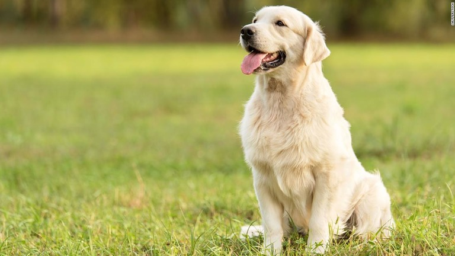

In [ ]:
# 必要な画像をダウンロードする。
import urllib.request

url = 'https://www.cnn.co.jp/storage/2020/07/04/c44b94ed74d3e50bd570738a2c97b65a/t/768/432/d/200703104728-labrador-retriever-stock-super-169.jpg'
urllib.request.urlretrieve(url, 'dog.jpg')  # 指定URLからdog.jpgとして保存

img = Image.open("dog.jpg")  #~ PillowでJPEGファイルを開く
transform = transforms.Compose(
    [transforms.Resize(256), # 短辺基準で256にリサイズ（アスペクト比維持）
     ]
)

# 関数呼び出しで変換を行う
trans_img = transform(img)
display(trans_img)

In [ ]:
# 次の平均、分散を用いて正規化
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet学習時のRGB平均
    std=[0.229, 0.224, 0.225])  # ImageNet学習時のRGB標準偏差

# 画像を256x256にリサイズ → 中央の224を切り取り
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

In [ ]:
# 画像の正規化
img_tensor = transform(img)  # (3,224,224) のテンソル生成

In [ ]:
# 各モデルを予測モードにする
feature_extractor = feature_extractor.eval()  # BatchNorm/Dropoutを推論挙動に固定
classifier = classifier.eval()

In [ ]:
# feature_extractorにより特徴マップを得る
feature = feature_extractor(img_tensor.view(-1,3,224,224))
print('特徴マップのサイズは　{}'.format(feature.shape))

特徴マップのサイズは　torch.Size([1, 512, 7, 7])


In [ ]:
# classifierにより分類を行います
predict = classifier(feature.view(-1,512*7*7))
print('予測されたクラスは {}'.format(torch.argmax(predict,1)))

予測されたクラスは tensor([207])


207: 'golden retriever',
https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a

#2. GradCamの実装

In [ ]:
# グレースケールをヒートマップにする関数
# 得られたグレースケールの注目箇所をヒートマップに変換する際に用います
def toHeatmap(x):
    x = (x*255).reshape(-1)
    cm = plt.get_cmap('jet')
    x = np.array([cm(int(np.round(xi)))[:3] for xi in x])
    return x.reshape(224,224,3)

In [ ]:
feature = feature_extractor(img_tensor.view(-1,3,224,224)) #特徴マップを計算
feature = feature.clone().detach().requires_grad_(True) #勾配を計算するようにコピー
y_pred = classifier(feature.view(-1,512*7*7)) #予測を行う
y_pred[0][torch.argmax(y_pred)].backward() # 予測でもっとも高い値をとったクラスの勾配を計算

# 以下は上記の式に倣って計算しています
alpha = torch.mean(feature.grad.view(512,7*7),1)
# feature を (C,H,W) に並べ替え（C=512, H=W=7）
feature = feature.view(512,7,7)
# 形状：(7,7)
L = F.relu(torch.sum(feature*alpha.view(-1,1,1),0)).cpu().detach().numpy()

# (0,1)になるように正規化
L_min = np.min(L)
L_max = np.max(L - L_min)
L = (L - L_min)/L_max

# 得られた注目度をヒートマップに変換
L = toHeatmap(cv2.resize(L,(224,224)))

In [ ]:
# 画像の正規化を戻すのに利用する
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
# ImageNet の平均・標準偏差。transform で正規化したものを元スケールに戻すために使用。

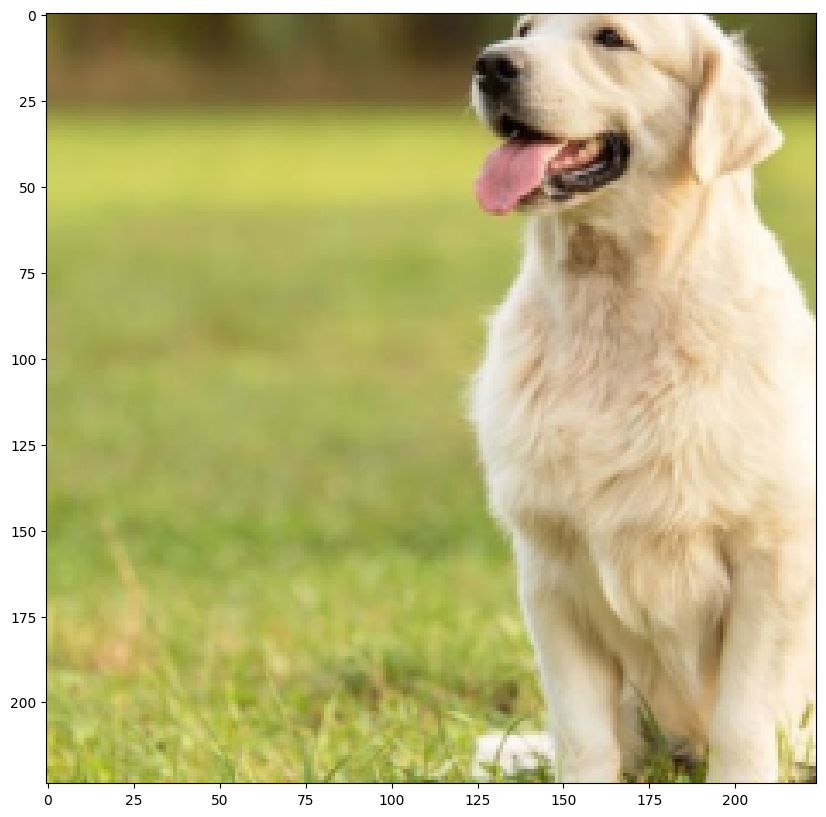

In [ ]:
# 予測に用いた画像は次のようになる(正規化は戻す)
plt.figure(figsize=(10,10))
plt.imshow((img_tensor*std + mean).permute(1,2,0).cpu().detach().numpy())

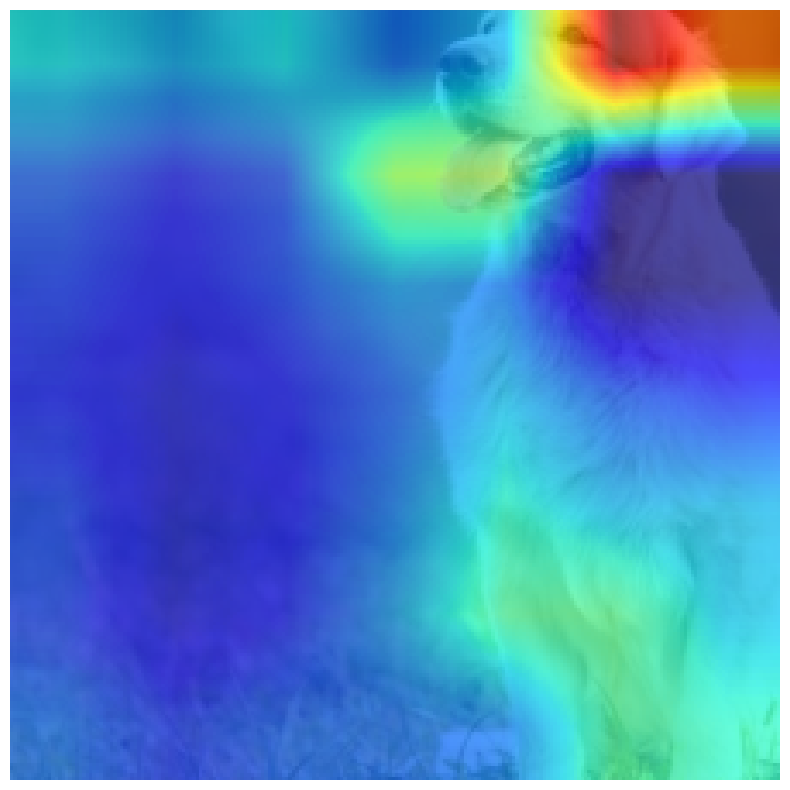

In [ ]:
# 元画像とヒートマップを α=0.3 で線形合成
img1 = (img_tensor*std + mean).permute(1,2,0).cpu().detach().numpy()
img2 = L
alpha = 0.3
blended = img1*alpha + img2*(1-alpha)
# 結果を表示する。
plt.figure(figsize=(10,10))
plt.imshow(blended)
plt.axis('off')
plt.show()

## 🔧 実践問題：ベースモデルをResNet18に変更してGrad-CAMを実装する

ここまではVGG16を使ってGrad-CAMを実装しました。
しかし、VGG16のように `features` / `classifier` で分離できるモデルばかりではありません。
ResNet等では構造が異なるため、特徴マップの取得方法を工夫する必要があります。

---

**問題：** 以下のコードの `______` を埋めて、ResNet18の最終畳み込み層（`layer4`）の出力に対するGrad-CAMを実装してください。

ResNet18の構造は以下の通りです：
```
ResNet18: conv1 → bn1 → relu → maxpool → layer1 → layer2 → layer3 → layer4 → avgpool → fc
```

PyTorchの `register_forward_hook` を使うと、モデルの途中の層の出力を取得できます。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
・<code>register_forward_hook</code> はコールバック関数 <code>hook_fn(module, input, output)</code> を登録し、その層が実行されたときに <code>output</code> を保存できます<br>
・勾配を取得するには <code>register_full_backward_hook</code> を同様に登録します<br>
・ResNet18の <code>layer4</code> の出力は <code>(batch, 512, 7, 7)</code> です
</blockquote>

</details>

<br/>

In [ ]:
# ResNet18でGrad-CAMを実装する
import cv2

resnet = models.resnet18(pretrained=True).eval()

# hookで特徴マップと勾配を保存するための変数
feature_maps = {}
gradients = {}

def forward_hook(module, input, output):
    feature_maps['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# TODO: ResNet18のどの層にhookを登録すべきか、______を埋めてください
resnet.______.register_forward_hook(forward_hook)
resnet.______.register_full_backward_hook(backward_hook)

# 順伝播
output = resnet(img_tensor.unsqueeze(0))
pred_class = torch.argmax(output, dim=1).item()
print(f'予測クラス: {pred_class}')

# 逆伝播
resnet.zero_grad()
output[0, pred_class].backward()

# TODO: hookで保存した勾配と特徴マップからGrad-CAMを計算してください
# alpha_k = 勾配の空間方向の平均 → 各チャネルの重み
grads = gradients['value'].squeeze()         # (512, 7, 7)
fmaps = feature_maps['value'].squeeze()      # (512, 7, 7)
alpha_k = torch.mean(grads.view(______, ______), dim=______)  # (512,)

# 加重和 + ReLU
cam = F.relu(torch.sum(fmaps * alpha_k.view(-1, 1, 1), dim=0)).cpu().numpy()  # (7,7)

# 正規化と可視化
cam = (cam - cam.min()) / (cam.max() - cam.min())
cam = toHeatmap(cv2.resize(cam, (224, 224)))

img_orig = (img_tensor * std + mean).permute(1, 2, 0).cpu().numpy()
blended = img_orig * 0.3 + cam * 0.7
plt.figure(figsize=(10, 10))
plt.title(f'Grad-CAM (ResNet18, class {pred_class})')
plt.imshow(blended)
plt.axis('off')
plt.show()

<details><summary>解答例</summary>

```python
# hookの登録先
resnet.layer4.register_forward_hook(forward_hook)
resnet.layer4.register_full_backward_hook(backward_hook)

# 勾配の空間平均の計算
alpha_k = torch.mean(grads.view(512, 7*7), dim=1)  # (512,)
```

VGG16では `features` / `classifier` を分離してGrad-CAMを実装できましたが、ResNetではその方法が使えません。
代わりに `register_forward_hook` / `register_full_backward_hook` を使って、
モデル内部の任意の層の出力と勾配をフック経由で取得します。

この手法はモデル構造に依存しない汎用的なGrad-CAM実装に応用できます。
hookの対象層を変えれば、浅い層（`layer1` など）のGrad-CAMも可視化でき、層ごとの注目領域の違いを比較できます。
</details>

# 📝 確認演習問題
以下の各問題について、（あ）（い）に当てはまる語句の正しい組み合わせを1〜4から選んでください。

---

## 問題1：Grad-CAMの目的

Grad-CAMは、CNNが入力画像のどの領域に注目して判断したかを **（あ）** として可視化する手法である。
これはモデルの **（い）** を高めるための技術として活用される。

```
1. （あ）ヒストグラム　（い）学習速度
2. （あ）ヒートマップ　（い）解釈可能性
3. （あ）ヒートマップ　（い）学習速度
4. （あ）ヒストグラム　（い）解釈可能性
```

<details><summary>正解</summary>

**2.（あ）ヒートマップ（い）解釈可能性**

Grad-CAMはモデルの注目領域を色の濃淡（ヒートマップ）で示す手法です。「なぜその判断をしたか」を視覚的に説明できるため、モデルの解釈可能性（Explainability）を高める技術として位置づけられます。
</details>

---

## 問題2：特徴抽出器と分類器の分離

VGG16のような分類モデルは、畳み込み層で構成される **（あ）** と、
全結合層で構成される **（い）** に大きく分けられる。Grad-CAMではこの2つを分離して処理する。

```
1. （あ）分類器　　　（い）特徴抽出器
2. （あ）特徴抽出器　（い）生成器
3. （あ）特徴抽出器　（い）分類器
4. （あ）生成器　　　（い）分類器
```

<details><summary>正解</summary>

**3.（あ）特徴抽出器（い）分類器**

VGG16の `.features` 部分（畳み込み＋プーリング）が特徴抽出器、`.classifier` 部分（全結合層）が分類器に対応します。Grad-CAMでは特徴抽出器の最終出力（特徴マップ）に対する勾配を利用します。
</details>

---

## 問題3：Grad-CAMにおける勾配の利用

Grad-CAMでは、対象クラスのスコアに対して **（あ）** を実行し、最終畳み込み層の特徴マップに対する勾配を取得する。
この勾配の **（い）** 方向の平均を取ることで、各チャネルの重要度を表す重みを算出する。

```
1. （あ）順伝播　　（い）チャネル
2. （あ）逆伝播　　（い）空間（H×W）
3. （あ）逆伝播　　（い）チャネル
4. （あ）順伝播　　（い）空間（H×W）
```

<details><summary>正解</summary>

**2.（あ）逆伝播（い）空間（H×W）**

対象クラスのスコアから `.backward()` で逆伝播を行い、特徴マップの勾配を得ます。その勾配の空間方向（縦×横）のGlobal Average Poolingにより、各チャネルがそのクラスの判断にどれだけ寄与しているかの重み（スカラー値）を算出します。
</details>

---

## 問題4：ヒートマップの生成

Grad-CAMの最終ステップでは、算出した各チャネルの重みで特徴マップの **（あ）** を取り、
負の値をゼロに置き換える **（い）** を適用してヒートマップを生成する。

```
1. （あ）加重和　（い）ReLU
2. （あ）最大値　（い）ReLU
3. （あ）加重和　（い）Sigmoid
4. （あ）最大値　（い）Sigmoid
```

<details><summary>正解</summary>

**1.（あ）加重和（い）ReLU**

各チャネルの特徴マップに重みを掛けて合計（加重和）し、ReLUを適用して正の寄与のみを残します。正の値は対象クラスの判断に「ポジティブに貢献した領域」を表し、これがヒートマップの元になります。
</details>

---

## 問題5：Grad-CAMの可視化

生成されたヒートマップは元画像と重ね合わせて表示する。このとき、グレースケールのヒートマップを
人間が直感的に理解しやすいように **（あ）** を用いて疑似カラーに変換し、
元画像とヒートマップを一定の比率で **（い）** して最終的な可視化結果を得る。

```
1. （あ）ヒストグラム均等化　（い）連結（concatenate）
2. （あ）カラーマップ　　　　（い）線形合成（ブレンド）
3. （あ）カラーマップ　　　　（い）連結（concatenate）
4. （あ）ヒストグラム均等化　（い）線形合成（ブレンド）
```

<details><summary>正解</summary>

**2.（あ）カラーマップ（い）線形合成（ブレンド）**

Matplotlibの `plt.get_cmap()` 等でカラーマップ（例：jet）を適用してグレースケールを疑似カラーに変換し、元画像とα値で線形合成（ブレンド）して重ね合わせ表示します。
</details>